# Eigenoptions vs Tabular Option-Critic

SMDP Q-learning (Eigenoptions) vs Tabular Option-Critic on 11×11 FourRooms with a mid-training goal switch.


In [1]:
# imports
import os
import math

import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as path_effects
from scipy.special import expit, logsumexp
from tqdm import tqdm

os.makedirs('perfect plots', exist_ok=True)


In [ ]:
#hyperparameters for both agents.
HYPERPARAMS = {
    # Shared / env
    "num_episodes": 2000,
    "max_steps": 200,
    "goal_switch_episode": 500,
    "initial_goal": (0, 10),
    "switched_goal": (10, 10),
    "n_runs": 10,

    # Eigenoptions
    "gamma": 0.9,
    "alpha": 0.1,
    "epsilon_start": 1.0,
    "epsilon_min": 0.10,
    "num_options_to_use": 64,
    "epsilon_boost_after_switch": 0.5,

    # Tabular option-critic
    "toc_noptions": 4,
    "toc_discount": 0.99,
    "toc_lr_term": 0.25,
    "toc_lr_intra": 0.25,
    "toc_lr_critic": 0.5,
    "toc_epsilon": 0.1,
    "toc_temperature": 0.01,

    # Snapshots & evaluation
    "snapshot_early_offset": 200,
    "snapshot_mid_offset": 500,
    "phase_window": 100,
}


In [ ]:
# 11x11 FourRooms gridworld with doorway bottlenecks.
class FourRoomsEnv(gym.Env):

    def __init__(self, bottleneck_rewards=False, goal_state=(0, 10)):
        super().__init__()
        self.grid_size = 11
        self.max_steps = 200
        self.bottleneck_rewards = bottleneck_rewards
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Box(
            low=0.0,
            high=float(self.grid_size),
            shape=(6,),
            dtype=np.float32,
        )
        self.goal_state = goal_state
        self.walls = set()
        for i in range(self.grid_size):
            self.walls.add((5, i))
            self.walls.add((i, 5))
        self.doorway_list = [(5, 1), (5, 8), (2, 5), (9, 5)]
        for doorway in self.doorway_list:
            self.walls.remove(doorway)
        self.valid_states = []
        for r in range(self.grid_size):
            for c in range(self.grid_size):
                if (r, c) not in self.walls:
                    self.valid_states.append((r, c))
        self.state_to_idx = {
            state: idx for idx, state in enumerate(self.valid_states)
        }
        self.idx_to_state = {
            idx: state for state, idx in self.state_to_idx.items()
        }
        self.num_states = len(self.valid_states)
        self.current_state = None
        self.current_step = 0
        self.visited_doorways = set()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.visited_doorways.clear()
        idx = self.np_random.integers(0, len(self.valid_states))
        while self.valid_states[idx] == self.goal_state:
            idx = self.np_random.integers(0, len(self.valid_states))
        self.current_state = self.valid_states[idx]
        return self._get_obs(), {}

    def step(self, action):
        action = int(action)
        self.current_step += 1
        r, c = self.current_state
        if action == 0:
            r -= 1
        elif action == 1:
            c += 1
        elif action == 2:
            r += 1
        elif action == 3:
            c -= 1
        if (0 <= r < self.grid_size
                and 0 <= c < self.grid_size
                and (r, c) not in self.walls):
            self.current_state = (r, c)
        terminated = self.current_state == self.goal_state
        truncated = self.current_step >= self.max_steps
        reward = 1.0 if terminated else 0.0
        if (self.bottleneck_rewards
                and self.current_state in self.doorway_list
                and self.current_state not in self.visited_doorways):
            reward += 0.5
            self.visited_doorways.add(self.current_state)
        return self._get_obs(), reward, terminated, truncated, {}

    def _get_obs(self):
        r, c = self.current_state
        obs = [float(r), float(c)]
        for doorway in self.doorway_list:
            obs.append(1.0 if doorway in self.visited_doorways else 0.0)
        return np.array(obs, dtype=np.float32)

    def get_state_idx(self):
        return self.state_to_idx[self.current_state]


In [ ]:
# Graph Laplacian and proto-value function computation.
def build_adjacency_matrix(env):
    #Build adjacency matrix from valid state transitions.
    num_states = env.num_states
    adjacency = np.zeros((num_states, num_states), dtype=np.float32)
    for state, state_idx in env.state_to_idx.items():
        r, c = state
        neighbors = [(r - 1, c), (r + 1, c), (r, c - 1), (r, c + 1)]
        for neighbor in neighbors:
            if neighbor in env.state_to_idx:
                adjacency[state_idx, env.state_to_idx[neighbor]] = 1.0
    return adjacency

def build_degree_matrix(A):
    #Diagonal degree matrix from adjacency matrix
    return np.diag(np.sum(A, axis=1))

def build_normalized_laplacian(A, D):
    #Normalized laplacian
    degrees = np.diag(D)
    d_inv_sqrt = 1.0 / np.sqrt(degrees + 1e-8)
    D_inv_sqrt = np.diag(d_inv_sqrt)
    return np.eye(A.shape[0]) - D_inv_sqrt @ A @ D_inv_sqrt

def compute_pvfs(L, discard_first=True):
    #eigendecomposition of L. discard_first drops the constant eigenvector (eigenvalue = 0).
    eigenvalues, eigenvectors = np.linalg.eigh(L)
    idx = np.argsort(eigenvalues)
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    if discard_first:
        eigenvalues = eigenvalues[1:]
        eigenvectors = eigenvectors[:, 1:]
    return eigenvalues, eigenvectors


In [5]:
# Policy iteration to derive eigenoptions from PVFs.
def get_deterministic_next_state(env, state_idx, action):
    """Next state index for a primitive action (walls block movement)."""
    r, c = env.idx_to_state[state_idx]
    next_r, next_c = r, c
    if action == 0:
        next_r -= 1
    elif action == 1:
        next_c += 1
    elif action == 2:
        next_r += 1
    elif action == 3:
        next_c -= 1
    if (0 <= next_r < env.grid_size
            and 0 <= next_c < env.grid_size
            and (next_r, next_c) not in env.walls):
        next_state = (next_r, next_c)
    else:
        next_state = (r, c)
    return env.state_to_idx[next_state]

def policy_iteration_eigenoption(env, eigenpurpose_vector, gamma=0.9, max_iters=1000, tol=1e-6):
    """Solve for the option policy maximising cumulative PVF-difference reward.

    env, eigenpurpose_vector (PVF column), gamma, max_iters, tol.
    Returns dict with policy (0-3 = primitive, 4 = terminate), Q, initiation/termination sets.
    """
    num_states = env.num_states
    num_actions = 4  # 0-3 primitive; index 4 = terminate
    policy = np.random.randint(0, num_actions, size=num_states)
    V = np.zeros(num_states)

    for _ in range(max_iters):
        for _ in range(1000):
            delta = 0.0
            new_V = np.zeros(num_states)
            for state_idx in range(num_states):
                action = policy[state_idx]
                if action == 4:
                    new_V[state_idx] = 0.0
                else:
                    next_state_idx = get_deterministic_next_state(env, state_idx, action)
                    reward = eigenpurpose_vector[next_state_idx] - eigenpurpose_vector[state_idx]
                    new_V[state_idx] = reward + gamma * V[next_state_idx]
                delta = max(delta, abs(new_V[state_idx] - V[state_idx]))
            V = new_V
            if delta < tol:
                break

        policy_stable = True
        Q = np.zeros((num_states, num_actions + 1))
        for state_idx in range(num_states):
            old_action = policy[state_idx]
            for action in range(num_actions):
                next_state_idx = get_deterministic_next_state(env, state_idx, action)
                reward = eigenpurpose_vector[next_state_idx] - eigenpurpose_vector[state_idx]
                Q[state_idx, action] = reward + gamma * V[next_state_idx]
            Q[state_idx, 4] = 0.0
            best_action = np.argmax(Q[state_idx])
            policy[state_idx] = best_action
            if old_action != best_action:
                policy_stable = False

        if policy_stable:
            break

    initiation_set = []
    termination_set = []
    for state_idx in range(num_states):
        max_primitive_q = np.max(Q[state_idx, :4])
        if max_primitive_q > 0:
            initiation_set.append(state_idx)
            policy[state_idx] = np.argmax(Q[state_idx, :4])
        else:
            policy[state_idx] = 4
            termination_set.append(state_idx)

    return {"policy": policy, "Q": Q, "initiation_set": initiation_set, "termination_set": termination_set}

def build_option_bank(env, eigenvalues, eigenvectors, gamma):
    """Build positive and negative eigenoptions for each PVF."""
    options_bank = []
    num_eigenvectors = eigenvectors.shape[1]
    with tqdm(total=num_eigenvectors * 2, desc="Building Option Bank") as pbar:
        for i in range(num_eigenvectors):
            pvf = eigenvectors[:, i]
            for direction, vec in [("positive", pvf), ("negative", -pvf)]:
                opt = policy_iteration_eigenoption(env, vec, gamma=gamma)
                options_bank.append({
                    "id": len(options_bank),
                    "eigenvalue": eigenvalues[i],
                    "direction": direction,
                    "policy": opt["policy"],
                    "initiation_set": opt["initiation_set"],
                    "termination_set": opt["termination_set"],
                })
                pbar.update(1)
    return options_bank

def prepare_smdp_options(options_bank, num_options):
    """Select the num_options lowest-eigenvalue options for SMDP."""
    sorted_options = sorted(options_bank, key=lambda x: x['eigenvalue'])
    return sorted_options[:num_options]


### Building Eigenoptions


In [6]:
# Compute PVFs and build the SMDP option bank.
env_eo = FourRoomsEnv(goal_state=HYPERPARAMS["initial_goal"])

A = build_adjacency_matrix(env_eo)
D = build_degree_matrix(A)
L = build_normalized_laplacian(A, D)

eigenvalues, eigenvectors = compute_pvfs(L, discard_first=True)

options_bank = build_option_bank(
    env_eo,
    eigenvalues,
    eigenvectors,
    gamma=HYPERPARAMS["gamma"],
)

smdp_options = prepare_smdp_options(options_bank, HYPERPARAMS["num_options_to_use"])
print(f"Selected {len(smdp_options)} options for SMDP Q-Learning")


Building Option Bank: 100%|██████████| 206/206 [00:07<00:00, 27.95it/s]

Selected 64 options for SMDP Q-Learning


In [7]:
# SMDP Q-learning over primitive and eigenoption actions.
def smdp_q_learning(env, options, hyperparams):
    """SMDP Q-learning with primitive + eigenoption actions.

    env, options (list of eigenoption dicts), hyperparams.
    Returns Q_table, episode rewards/steps/success, q_snapshots.
    """
    num_states = env.num_states
    num_primitive = 4  # 0-3 primitive; 4+ = option indices
    num_options = len(options)
    total_actions = num_primitive + num_options

    Q_table = np.zeros((num_states, total_actions))

    epsilon = hyperparams["epsilon_start"]
    epsilon_min = hyperparams["epsilon_min"]
    epsilon_decay = hyperparams["epsilon_start"] / (hyperparams["num_episodes"] / 2)

    alpha = hyperparams["alpha"]
    gamma = hyperparams["gamma"]

    goal_switch_episode = hyperparams.get("goal_switch_episode", None)
    switched_goal = hyperparams.get("switched_goal", None)
    epsilon_boost_after_switch = hyperparams.get("epsilon_boost_after_switch", 0.5)
    early_offset = hyperparams["snapshot_early_offset"]
    mid_offset = hyperparams["snapshot_mid_offset"]

    episode_rewards = []
    episode_steps = []
    episode_success = []
    q_snapshots = {}
    goal_switched = False

    for episode in tqdm(range(hyperparams["num_episodes"]), desc="Training SMDP Agent"):
        if (goal_switch_episode is not None
                and episode == goal_switch_episode
                and not goal_switched):
            q_snapshots["before_switch"] = Q_table.copy()
            env.goal_state = switched_goal
            epsilon = max(epsilon, epsilon_boost_after_switch)  # re-explore after goal change
            goal_switched = True

        obs, _ = env.reset()
        state_idx = env.get_state_idx()

        total_reward = 0
        step = 0
        reached_goal = False

        while step < hyperparams["max_steps"]:
            valid_actions = list(range(num_primitive))
            for opt_idx, opt in enumerate(options):
                if state_idx in opt["initiation_set"]:
                    valid_actions.append(num_primitive + opt_idx)

            if np.random.rand() < epsilon:
                action_idx = int(np.random.choice(valid_actions))
            else:
                valid_q = Q_table[state_idx, valid_actions]
                max_q = np.max(valid_q)
                best_actions = [a for a, q in zip(valid_actions, valid_q) if q == max_q]
                action_idx = int(np.random.choice(best_actions))

            if action_idx < num_primitive:
                next_obs, reward, terminated, truncated, _ = env.step(action_idx)
                next_state_idx = env.get_state_idx()

                target = reward + (0 if terminated else gamma * np.max(Q_table[next_state_idx, :]))
                Q_table[state_idx, action_idx] += alpha * (target - Q_table[state_idx, action_idx])

                state_idx = next_state_idx
                total_reward += reward
                step += 1

                if terminated:
                    reached_goal = True
                if terminated or truncated:
                    break
            else:
                option_idx = action_idx - num_primitive
                option = options[option_idx]
                option_policy = option['policy']
                start_state_idx = state_idx

                k = 0
                option_reward = 0.0
                terminated, truncated = False, False

                while True:
                    if option_policy[state_idx] == 4:  # terminate
                        break

                    primitive_action = option_policy[state_idx]
                    next_obs, reward, terminated, truncated, _ = env.step(primitive_action)
                    next_state_idx = env.get_state_idx()

                    option_reward += (gamma ** k) * reward
                    k += 1

                    state_idx = next_state_idx
                    total_reward += reward
                    step += 1

                    if terminated:
                        reached_goal = True
                    if terminated or truncated:
                        break
                    if step >= hyperparams["max_steps"]:
                        break

                bootstrapped_value = 0.0
                if not (terminated or truncated):
                    bootstrapped_value = np.max(Q_table[state_idx, :])

                target = option_reward + (gamma ** k) * bootstrapped_value
                Q_table[start_state_idx, action_idx] += alpha * (target - Q_table[start_state_idx, action_idx])

                if terminated or truncated:
                    break

        epsilon = max(epsilon_min, epsilon - epsilon_decay)
        episode_rewards.append(total_reward)
        episode_steps.append(step)
        episode_success.append(1.0 if reached_goal else 0.0)

        if goal_switch_episode is not None and goal_switched:
            if episode == goal_switch_episode + early_offset:
                q_snapshots["early_adaptation"] = Q_table.copy()
            elif episode == goal_switch_episode + mid_offset:
                q_snapshots["mid_adaptation"] = Q_table.copy()

    q_snapshots["final"] = Q_table.copy()
    return Q_table, episode_rewards, episode_steps, episode_success, q_snapshots


### Running Eigenoptions Training


In [8]:
# Train Eigenoptions agent across multiple independent runs.
N_RUNS = HYPERPARAMS["n_runs"]

eo_rewards_all = []
eo_steps_all = []
eo_success_all = []
eo_q_snapshots_all = []
final_eo_agent_Q = None

for run in range(N_RUNS):
    print(f"--- SMDP Run {run+1}/{N_RUNS} ---")
    env_eo = FourRoomsEnv(goal_state=HYPERPARAMS["initial_goal"])
    Q_table, r, s, suc, qs = smdp_q_learning(env_eo, smdp_options, HYPERPARAMS)
    eo_rewards_all.append(r)
    eo_steps_all.append(s)
    eo_success_all.append(suc)
    eo_q_snapshots_all.append(qs)
    if run == N_RUNS - 1:
        final_eo_agent_Q = Q_table

q_snapshots = eo_q_snapshots_all[-1]
print(f"Eigenoptions {N_RUNS}x Training Complete!")


--- SMDP Run 1/10 ---


Training SMDP Agent: 100%|██████████| 2000/2000 [00:01<00:00, 1649.05it/s]


--- SMDP Run 2/10 ---


Training SMDP Agent: 100%|██████████| 2000/2000 [00:01<00:00, 1690.02it/s]


--- SMDP Run 3/10 ---


...

--- SMDP Run 9/10 ---


Training SMDP Agent: 100%|██████████| 2000/2000 [00:01<00:00, 1881.95it/s]


--- SMDP Run 10/10 ---


Training SMDP Agent: 100%|██████████| 2000/2000 [00:01<00:00, 1688.26it/s]

Eigenoptions 10x Training Complete!


### Tabular Option-Critic Components


In [9]:
# Tabular option-critic policy, termination, and critic classes.
class EpsGreedyPolicy:
    def __init__(self, rng, nstates, noptions, epsilon):
        self.rng = rng
        self.nstates = nstates
        self.noptions = noptions
        self.epsilon = epsilon
        self.Q_Omega_table = np.zeros((nstates, noptions))

    def Q_Omega(self, state, option=None):
        if option is None:
            return self.Q_Omega_table[state, :]
        return self.Q_Omega_table[state, option]

    def sample(self, state):
        if self.rng.uniform() < self.epsilon:
            return int(self.rng.randint(self.noptions))
        return int(np.argmax(self.Q_Omega(state)))

class SoftmaxPolicy:
    def __init__(self, rng, lr, nstates, nactions, temperature=1.0):
        self.rng = rng
        self.lr = lr
        self.nstates = nstates
        self.nactions = nactions
        self.temperature = temperature
        self.weights = np.zeros((nstates, nactions))

    def Q_U(self, state, action=None):
        if action is None:
            return self.weights[state, :]
        return self.weights[state, action]

    def pmf(self, state):
        exponent = self.Q_U(state) / self.temperature
        return np.exp(exponent - logsumexp(exponent))

    def sample(self, state):
        return int(self.rng.choice(self.nactions, p=self.pmf(state)))

    def update(self, state, action, Q_U):
        actions_pmf = self.pmf(state)
        self.weights[state, :] -= self.lr * actions_pmf * Q_U
        self.weights[state, action] += self.lr * Q_U

class SigmoidTermination:
    def __init__(self, rng, lr, nstates):
        self.rng = rng
        self.lr = lr
        self.nstates = nstates
        self.weights = np.zeros((nstates,))

    def pmf(self, state):
        return expit(self.weights[state])

    def sample(self, state):
        return int(self.rng.uniform() < self.pmf(state))

    def gradient(self, state):
        return self.pmf(state) * (1.0 - self.pmf(state)), state

    def update(self, state, advantage):
        magnitude, direction = self.gradient(state)
        self.weights[direction] -= self.lr * magnitude * advantage

class Critic:
    def __init__(self, lr, discount, Q_Omega_table, nstates, noptions, nactions):
        self.lr = lr
        self.discount = discount
        self.Q_Omega_table = Q_Omega_table  # shared by ref with policy_over_options
        self.Q_U_table = np.zeros((nstates, noptions, nactions))

    def cache(self, state, option, action):
        self.last_state = state
        self.last_option = option
        self.last_action = action
        self.last_Q_Omega = self.Q_Omega(state, option)

    def Q_Omega(self, state, option=None):
        if option is None:
            return self.Q_Omega_table[state, :]
        return self.Q_Omega_table[state, option]

    def Q_U(self, state, option, action):
        return self.Q_U_table[state, option, action]

    def A_Omega(self, state, option=None):
        advantage = self.Q_Omega(state) - np.max(self.Q_Omega(state))
        if option is None:
            return advantage
        return advantage[option]

    def update_Qs(self, state, option, action, reward, done, terminations):
        target = reward
        if not done:
            beta_omega = terminations[self.last_option].pmf(state)
            target += self.discount * (
                (1.0 - beta_omega) * self.Q_Omega(state, self.last_option)
                + beta_omega * np.max(self.Q_Omega(state))
            )

        tderror_Q_Omega = target - self.last_Q_Omega
        self.Q_Omega_table[self.last_state, self.last_option] += self.lr * tderror_Q_Omega

        tderror_Q_U = target - self.Q_U(self.last_state, self.last_option, self.last_action)
        self.Q_U_table[self.last_state, self.last_option, self.last_action] += self.lr * tderror_Q_U

        self.last_state = state
        self.last_option = option
        self.last_action = action
        if not done:
            self.last_Q_Omega = self.Q_Omega(state, option)


In [10]:
# Tabular option-critic training loop.
def train_toc(env, hyperparams):
    """Train tabular option-critic on env with mid-training goal switch.

    env, hyperparams.
    Returns episode rewards/steps/success, q_snapshots, policy_over_options, option_policies, option_terminations.
    """
    nstates = env.num_states
    nactions = env.action_space.n
    noptions = hyperparams["toc_noptions"]

    rng = np.random.RandomState(1234)  # fixed seed for reproducibility
    option_policies = [
        SoftmaxPolicy(rng, hyperparams["toc_lr_intra"], nstates, nactions, hyperparams["toc_temperature"])
        for _ in range(noptions)
    ]
    option_terminations = [
        SigmoidTermination(rng, hyperparams["toc_lr_term"], nstates)
        for _ in range(noptions)
    ]
    policy_over_options = EpsGreedyPolicy(rng, nstates, noptions, hyperparams["toc_epsilon"])
    critic = Critic(
        hyperparams["toc_lr_critic"], hyperparams["toc_discount"],
        policy_over_options.Q_Omega_table, nstates, noptions, nactions,
    )

    episode_rewards = []
    episode_steps = []
    episode_success = []
    q_snapshots = {}

    goal_switch_episode = hyperparams.get("goal_switch_episode", None)
    switched_goal = hyperparams.get("switched_goal", None)
    goal_switched = False
    early_offset = hyperparams["snapshot_early_offset"]
    mid_offset = hyperparams["snapshot_mid_offset"]

    for episode in tqdm(range(hyperparams["num_episodes"]), desc="Training TOC Agent"):
        if (goal_switch_episode is not None
                and episode == goal_switch_episode
                and not goal_switched):
            q_snapshots["before_switch"] = policy_over_options.Q_Omega_table.copy()
            env.goal_state = switched_goal
            goal_switched = True

        env.reset()
        state = env.get_state_idx()

        option = policy_over_options.sample(state)
        action = option_policies[option].sample(state)
        critic.cache(state, option, action)

        total_reward = 0
        step = 0
        reached_goal = False

        while step < hyperparams["max_steps"]:
            _, reward, terminated, truncated, _ = env.step(action)
            state = env.get_state_idx()

            total_reward += reward
            step += 1

            if terminated:
                reached_goal = True

            terminated_option = option_terminations[option].sample(state)

            if terminated_option:
                option = policy_over_options.sample(state)

            action = option_policies[option].sample(state)

            critic.update_Qs(state, option, action, reward, terminated, option_terminations)

            Q_U = critic.Q_U(state, option, action)
            Q_U = Q_U - critic.Q_Omega(state, option)
            option_policies[option].update(state, action, Q_U)
            option_terminations[option].update(state, critic.A_Omega(state, option))

            if terminated or truncated:
                break

        episode_rewards.append(total_reward)
        episode_steps.append(step)
        episode_success.append(1.0 if reached_goal else 0.0)

        if goal_switch_episode is not None and goal_switched:
            if episode == goal_switch_episode + early_offset:
                q_snapshots["early_adaptation"] = policy_over_options.Q_Omega_table.copy()
            elif episode == goal_switch_episode + mid_offset:
                q_snapshots["mid_adaptation"] = policy_over_options.Q_Omega_table.copy()

    q_snapshots["final"] = policy_over_options.Q_Omega_table.copy()
    return episode_rewards, episode_steps, episode_success, q_snapshots, policy_over_options, option_policies, option_terminations


### Running TOC Training


In [11]:
# Train TOC agent across multiple independent runs.
N_RUNS = HYPERPARAMS["n_runs"]

toc_rewards_all = []
toc_steps_all = []
toc_success_all = []
toc_q_snapshots_all = []
final_toc_agent = None

for run in range(N_RUNS):
    print(f"--- TOC Run {run+1}/{N_RUNS} ---")
    env_toc = FourRoomsEnv(goal_state=HYPERPARAMS["initial_goal"])
    r, s, suc, qs, po, op, ot = train_toc(env_toc, HYPERPARAMS)
    toc_rewards_all.append(r)
    toc_steps_all.append(s)
    toc_success_all.append(suc)
    toc_q_snapshots_all.append(qs)
    if run == N_RUNS - 1:
        final_toc_agent = (po, op, ot)

toc_q_snapshots = toc_q_snapshots_all[-1]
print(f"TOC {N_RUNS}x Training Complete!")


--- TOC Run 1/10 ---


Training TOC Agent: 100%|██████████| 2000/2000 [01:07<00:00, 29.75it/s] 


--- TOC Run 2/10 ---


Training TOC Agent: 100%|██████████| 2000/2000 [00:49<00:00, 40.13it/s] 


--- TOC Run 3/10 ---


...

--- TOC Run 9/10 ---


Training TOC Agent: 100%|██████████| 2000/2000 [00:55<00:00, 35.89it/s]


--- TOC Run 10/10 ---


Training TOC Agent: 100%|██████████| 2000/2000 [00:26<00:00, 75.39it/s] 

TOC 10x Training Complete!


### Visualization Utilities


In [12]:
# Plot styling, color palette, and grid drawing helpers.
COLORS = {
    "primary": "#3498db",
    "secondary": "#2ecc71",
    "accent": "#e74c3c",
    "neutral": "#95a5a6",
    "text": "#2c3e50",
    "text_muted": "#7f8c8d",
    "background": "#ffffff",
    "panel": "#f8f9fa",
    "grid": "#ecf0f1",
    "floor": "#ffffff",
    "wall": "#34495e",
    "goal": "#e74c3c",
    "start": "#2ecc71",
    "terminate": "#e67e22",
    "primitive": "#95a5a6",
}

FONT_STACK = {
    "title":    {"size": 13, "weight": "bold", "color": COLORS["text"]},
    "subtitle": {"size": 10, "style": "italic", "color": COLORS["text_muted"]},
    "axis":     {"size": 11, "weight": "medium", "color": COLORS["text"]},
    "tick":     {"size": 9},
    "legend":   {"size": 9},
}

PLOT_DEFAULTS = {
    "grid_alpha": 0.3,
    "grid_color": COLORS["grid"],
    "grid_linewidth": 1.0,
    "alpha_raw": 0.25,
    "alpha_smooth": 0.9,
}

def style_axes(ax, grid=True, spines=("left", "bottom")):
    """Apply consistent axis styling."""
    for s in ["top", "right", "left", "bottom"]:
        ax.spines[s].set_visible(s in spines)
    ax.tick_params(colors=COLORS["text_muted"], which="both",
                   length=3, width=0.7)
    if grid:
        ax.grid(True, color=PLOT_DEFAULTS["grid_color"],
                alpha=PLOT_DEFAULTS["grid_alpha"],
                linewidth=PLOT_DEFAULTS["grid_linewidth"])
        ax.set_axisbelow(True)
    else:
        ax.grid(False)
    return ax

def set_title(ax, title, subtitle=None):
    """Left-aligned title with optional italic subtitle."""
    pad = 28 if subtitle else 8
    ax.set_title(title, loc="left", pad=pad,
                 fontsize=FONT_STACK["title"]["size"],
                 fontweight=FONT_STACK["title"]["weight"],
                 color=FONT_STACK["title"]["color"])
    if subtitle:
        ax.text(0, 1.05, subtitle, transform=ax.transAxes,
                fontsize=FONT_STACK["subtitle"]["size"],
                color=FONT_STACK["subtitle"]["color"],
                style=FONT_STACK["subtitle"]["style"],
                ha="left", va="bottom")

def fig_title(fig, title, subtitle=None, y=0.99):
    """Figure-level suptitle with optional subtitle."""
    fig.suptitle(title, x=0.01, y=y, ha="left", va="top",
                 fontsize=FONT_STACK["title"]["size"] + 2,
                 fontweight=FONT_STACK["title"]["weight"],
                 color=FONT_STACK["title"]["color"])
    if subtitle:
        offset = 0.5 / fig.get_figheight()
        fig.text(0.01, y - offset, subtitle, ha="left", va="top",
                 fontsize=FONT_STACK["subtitle"]["size"],
                 color=FONT_STACK["subtitle"]["color"],
                 style=FONT_STACK["subtitle"]["style"])

def rolling_avg(data, w):
    """Rolling mean with window w (returns shorter array)."""
    if len(data) < w:
        return np.array([])
    return np.convolve(data, np.ones(w) / w, mode="valid")

def draw_env_grid(ax, env, coord_system="inverted"):
    """Draw the FourRooms grid (walls, floor, goal) on ax."""
    if coord_system == "inverted":
        yt = lambda r: env.grid_size - 1 - r
        offset = -0.5
        lim_lo, lim_hi = -0.5, env.grid_size - 0.5
    else:
        yt = lambda r: r
        offset = 0
        lim_lo, lim_hi = 0, env.grid_size
    for r in range(env.grid_size):
        for c in range(env.grid_size):
            if (r, c) not in env.walls:
                ax.add_patch(plt.Rectangle(
                    (c + offset, yt(r) + offset), 1, 1,
                    facecolor=COLORS["floor"],
                    edgecolor=COLORS["grid"],
                    linewidth=0.3, zorder=1,
                ))
    for (r, c) in env.walls:
        ax.add_patch(plt.Rectangle(
            (c + offset, yt(r) + offset), 1, 1,
            facecolor=COLORS["wall"], edgecolor="none", zorder=2,
        ))
    gr, gc = env.goal_state
    ax.add_patch(plt.Rectangle(
        (gc + offset, yt(gr) + offset), 1, 1,
        facecolor=COLORS["goal"], alpha=0.18, edgecolor="none", zorder=2,
    ))
    ax.set_xlim(lim_lo, lim_hi)
    ax.set_ylim(lim_lo, lim_hi)
    if coord_system == "natural":
        ax.set_ylim(lim_hi, lim_lo)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ["top", "right", "left", "bottom"]:
        ax.spines[s].set_visible(False)
    ax.grid(False)
    ax.set_facecolor(COLORS["background"])
    return ax

def plot_value_evolution(env, q_snapshots, hyperparams, title):
    """Plot V = max(Q) heatmaps across training snapshots."""
    initial_goal = hyperparams.get("initial_goal", (0, 10))
    switched_goal = hyperparams.get("switched_goal", (10, 10))

    panels = []
    if "before_switch" in q_snapshots:
        panels.append(("Before Goal Switch", q_snapshots["before_switch"], initial_goal))
    if "early_adaptation" in q_snapshots:
        panels.append(("Early Adaptation\n(+200 eps)", q_snapshots["early_adaptation"], switched_goal))
    if "mid_adaptation" in q_snapshots:
        panels.append(("Mid Adaptation\n(+500 eps)", q_snapshots["mid_adaptation"], switched_goal))
    if "final" in q_snapshots:
        panels.append(("After Training", q_snapshots["final"], switched_goal))

    n = len(panels)
    if n == 0:
        print("No Q-table snapshots available.")
        return

    fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, (panel_title, q_table, goal) in zip(axes, panels):
        V = np.max(q_table, axis=1)
        grid_V = np.full((env.grid_size, env.grid_size), np.nan)
        for state, idx in env.state_to_idx.items():
            r, c = state
            grid_V[r, c] = V[idx]

        masked_V = np.ma.masked_invalid(grid_V)
        im = ax.imshow(masked_V, cmap="viridis", aspect="auto", interpolation="nearest")

        gr, gc = goal
        ax.plot(gc, gr, "*", markersize=25, color=COLORS["accent"],
                markeredgecolor="white", markeredgewidth=2, zorder=10)

        set_title(ax, panel_title, f"Goal at {goal}")
        style_axes(ax, grid=False, spines=("left", "bottom"))

        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(colors=COLORS["text_muted"],
                            labelsize=FONT_STACK["tick"]["size"], length=2, width=0.5)
        cbar.outline.set_edgecolor(COLORS["text_muted"])
        cbar.outline.set_linewidth(0.5)

    fig_title(fig, title, y=1.02)
    plt.tight_layout()


### Comparative Dashboard


/tmp/ipykernel_10553/1349991350.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


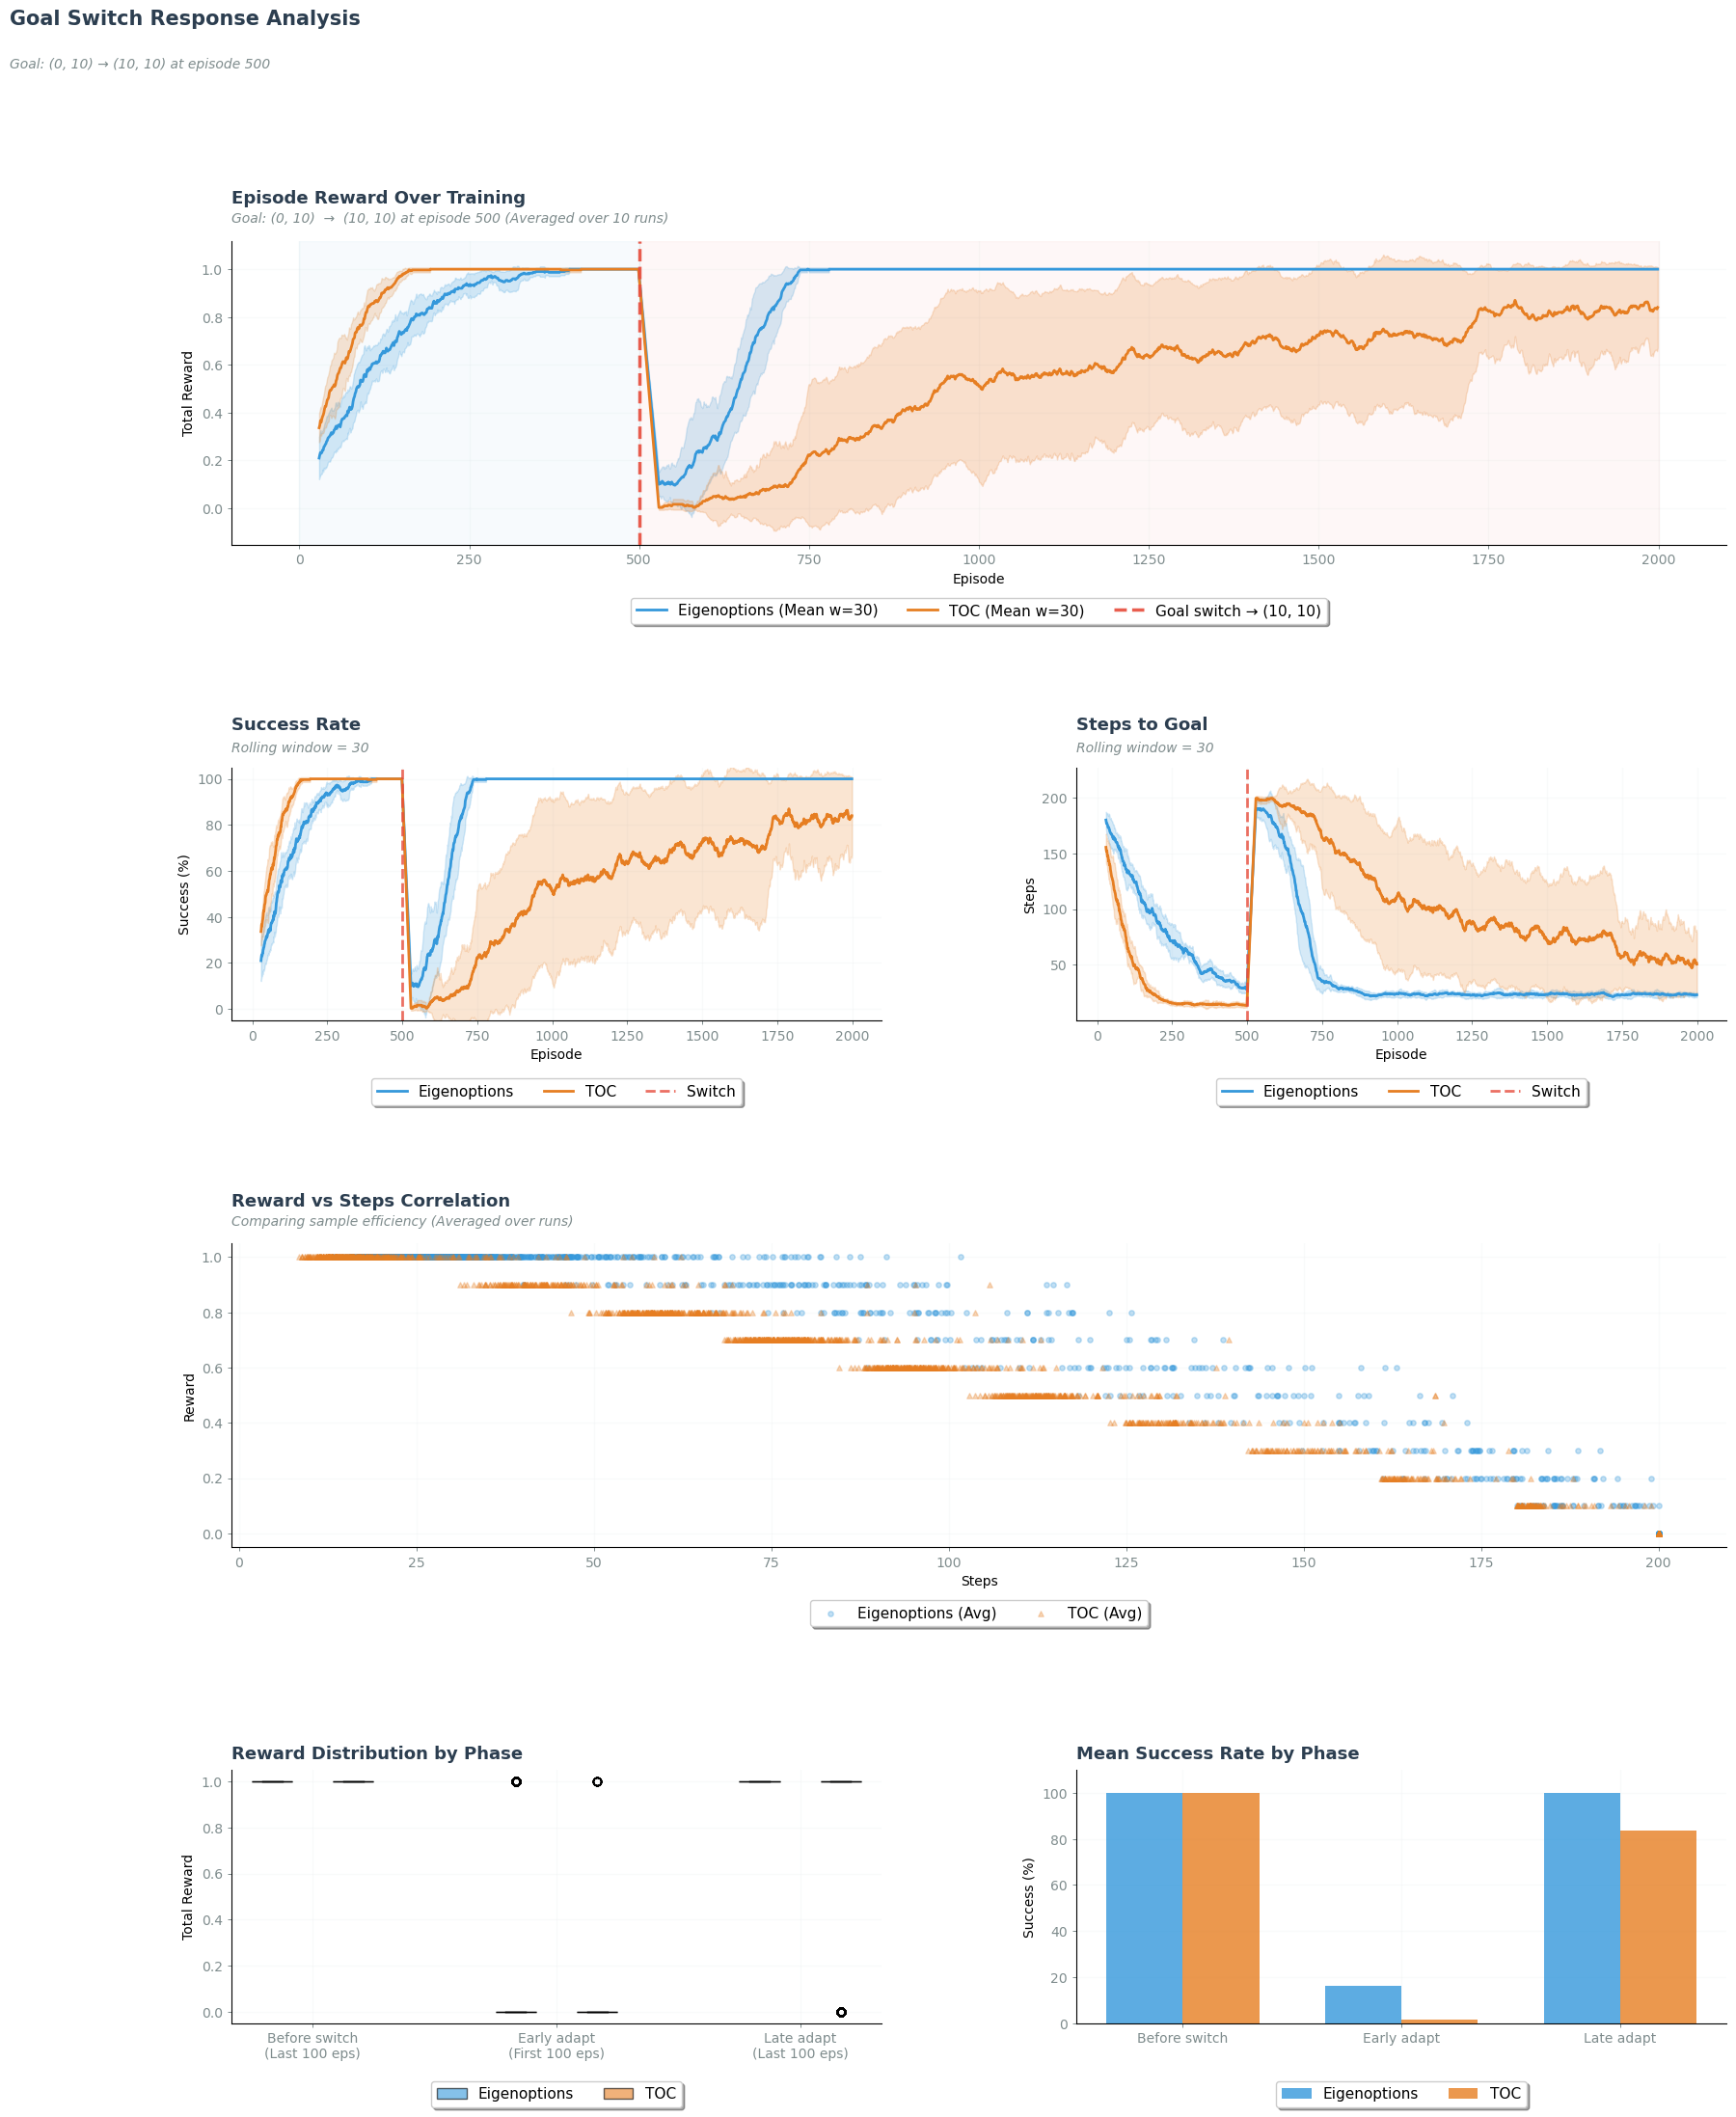

In [13]:
# Comparative training dashboard: rewards, success, steps, phases.
def plot_comparative_dashboard(eo_rewards_all, eo_steps_all, eo_success_all,
                               toc_rewards_all, toc_steps_all, toc_success_all,
                               hyperparams, window=30):
    """Multi-panel dashboard comparing EO and TOC training curves and phase summaries."""
    goal_switch = hyperparams.get("goal_switch_episode", None)
    num_episodes = len(eo_rewards_all[0])
    initial_goal = hyperparams.get("initial_goal", (0, 10))
    switched_goal = hyperparams.get("switched_goal", (10, 10))
    phase_window = hyperparams["phase_window"]

    fig = plt.figure(figsize=(20, 24))
    gs = fig.add_gridspec(4, 2, hspace=0.8, wspace=0.3, height_ratios=[1.2, 1, 1.2, 1])

    eo_color = "#3498db"
    toc_color = "#e67e22"

    def smooth_and_stats(data_all):
        smoothed = np.array([rolling_avg(d, window) for d in data_all])
        if smoothed.size == 0 or smoothed.shape[1] == 0:
            return np.array([]), np.array([])
        return np.mean(smoothed, axis=0), np.std(smoothed, axis=0)

    x = np.arange(window - 1, num_episodes)

    # Row 1: reward curve (full width)
    ax1 = fig.add_subplot(gs[0, :])
    rw_eo_m, rw_eo_s = smooth_and_stats(eo_rewards_all)
    rw_toc_m, rw_toc_s = smooth_and_stats(toc_rewards_all)
    if len(rw_eo_m) > 0:
        ax1.plot(x, rw_eo_m, color=eo_color, linewidth=2, label=f"Eigenoptions (Mean w={window})")
        ax1.fill_between(x, rw_eo_m - rw_eo_s, rw_eo_m + rw_eo_s, color=eo_color, alpha=0.2)
    if len(rw_toc_m) > 0:
        ax1.plot(x, rw_toc_m, color=toc_color, linewidth=2, label=f"TOC (Mean w={window})")
        ax1.fill_between(x, rw_toc_m - rw_toc_s, rw_toc_m + rw_toc_s, color=toc_color, alpha=0.2)

    if goal_switch is not None:
        ax1.axvline(x=goal_switch, color=COLORS["accent"], linestyle="--",
                    linewidth=2.5, alpha=0.9, zorder=5, label=f"Goal switch → {switched_goal}")
        ax1.axvspan(0, goal_switch, alpha=0.04, color=eo_color)
        ax1.axvspan(goal_switch, num_episodes, alpha=0.04, color=COLORS["accent"])

    set_title(ax1, "Episode Reward Over Training",
              f"Goal: {initial_goal}  →  {switched_goal} at episode {goal_switch} (Averaged over {len(eo_rewards_all)} runs)")
    ax1.set_xlabel("Episode")
    ax1.set_ylabel("Total Reward")
    style_axes(ax1)
    ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), fontsize=11, ncol=3, fancybox=True, shadow=True)

    # Row 2 left: success rate
    ax2 = fig.add_subplot(gs[1, 0])
    sw_eo_m, sw_eo_s = smooth_and_stats([np.array(d) * 100 for d in eo_success_all])
    sw_toc_m, sw_toc_s = smooth_and_stats([np.array(d) * 100 for d in toc_success_all])
    if len(sw_eo_m) > 0:
        ax2.plot(x, sw_eo_m, color=eo_color, linewidth=2, label="Eigenoptions")
        ax2.fill_between(x, sw_eo_m - sw_eo_s, sw_eo_m + sw_eo_s, color=eo_color, alpha=0.2)
    if len(sw_toc_m) > 0:
        ax2.plot(x, sw_toc_m, color=toc_color, linewidth=2, label="TOC")
        ax2.fill_between(x, sw_toc_m - sw_toc_s, sw_toc_m + sw_toc_s, color=toc_color, alpha=0.2)
    if goal_switch is not None:
        ax2.axvline(x=goal_switch, color=COLORS["accent"], linestyle="--", linewidth=2, alpha=0.8, label="Switch")

    set_title(ax2, "Success Rate", f"Rolling window = {window}")
    ax2.set_xlabel("Episode")
    ax2.set_ylabel("Success (%)")
    ax2.set_ylim(-5, 105)
    style_axes(ax2)
    ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), fontsize=11, ncol=3, fancybox=True, shadow=True)

    # Row 2 right: episode length
    ax3 = fig.add_subplot(gs[1, 1])
    stw_eo_m, stw_eo_s = smooth_and_stats(eo_steps_all)
    stw_toc_m, stw_toc_s = smooth_and_stats(toc_steps_all)
    if len(stw_eo_m) > 0:
        ax3.plot(x, stw_eo_m, color=eo_color, linewidth=2, label="Eigenoptions")
        ax3.fill_between(x, stw_eo_m - stw_eo_s, stw_eo_m + stw_eo_s, color=eo_color, alpha=0.2)
    if len(stw_toc_m) > 0:
        ax3.plot(x, stw_toc_m, color=toc_color, linewidth=2, label="TOC")
        ax3.fill_between(x, stw_toc_m - stw_toc_s, stw_toc_m + stw_toc_s, color=toc_color, alpha=0.2)
    if goal_switch is not None:
        ax3.axvline(x=goal_switch, color=COLORS["accent"], linestyle="--", linewidth=2, alpha=0.8, label="Switch")

    set_title(ax3, "Steps to Goal", f"Rolling window = {window}")
    ax3.set_xlabel("Episode")
    ax3.set_ylabel("Steps")
    style_axes(ax3)
    ax3.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), fontsize=11, ncol=3, fancybox=True, shadow=True)

    # Row 3: reward vs steps scatter (full width)
    ax4 = fig.add_subplot(gs[2, :])
    eo_rewards_avg = np.mean(eo_rewards_all, axis=0)
    eo_steps_avg = np.mean(eo_steps_all, axis=0)
    toc_rewards_avg = np.mean(toc_rewards_all, axis=0)
    toc_steps_avg = np.mean(toc_steps_all, axis=0)
    ax4.scatter(eo_steps_avg, eo_rewards_avg, color=eo_color, alpha=0.3, s=15, label="Eigenoptions (Avg)", marker='o')
    ax4.scatter(toc_steps_avg, toc_rewards_avg, color=toc_color, alpha=0.3, s=15, label="TOC (Avg)", marker='^')
    set_title(ax4, "Reward vs Steps Correlation", "Comparing sample efficiency (Averaged over runs)")
    ax4.set_xlabel("Steps")
    ax4.set_ylabel("Reward")
    style_axes(ax4, grid=True)
    ax4.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), fontsize=11, ncol=2, fancybox=True, shadow=True)

    # Phase windows for distribution and summary plots
    phase_ranges = [
        (max(0, goal_switch - phase_window), goal_switch),
        (goal_switch, goal_switch + phase_window),
        (max(0, num_episodes - phase_window), num_episodes),
    ]

    def get_phase_data(data_all, start, end):
        d = []
        for r_all in data_all:
            d.extend(r_all[start:end])
        return d

    def mean_success(data_all, start, end):
        return np.mean([np.mean(run[start:end]) for run in data_all]) * 100

    # Row 4 left: reward distribution by phase
    ax5 = fig.add_subplot(gs[3, 0])
    if goal_switch is not None:
        data_eo = [get_phase_data(eo_rewards_all, s, e) for s, e in phase_ranges]
        data_toc = [get_phase_data(toc_rewards_all, s, e) for s, e in phase_ranges]

        positions_eo = [1, 4, 7]
        positions_toc = [2, 5, 8]

        bp_eo = ax5.boxplot(data_eo, positions=positions_eo, patch_artist=True,
                            boxprops=dict(facecolor=eo_color, alpha=0.6), medianprops=dict(color="black"))
        bp_toc = ax5.boxplot(data_toc, positions=positions_toc, patch_artist=True,
                             boxprops=dict(facecolor=toc_color, alpha=0.6), medianprops=dict(color="black"))

        ax5.set_xticks([1.5, 4.5, 7.5])
        ax5.set_xticklabels(["Before switch\n(Last 100 eps)", "Early adapt\n(First 100 eps)", "Late adapt\n(Last 100 eps)"])

        ax5.legend([bp_eo["boxes"][0], bp_toc["boxes"][0]], ["Eigenoptions", "TOC"],
                   loc="upper center", bbox_to_anchor=(0.5, -0.2), fontsize=11, ncol=2, fancybox=True, shadow=True)

    set_title(ax5, "Reward Distribution by Phase")
    ax5.set_ylabel("Total Reward")
    style_axes(ax5, grid=True)

    # Row 4 right: mean success rate by phase
    ax6 = fig.add_subplot(gs[3, 1])
    if goal_switch is not None:
        rates_eo = [mean_success(eo_success_all, s, e) for s, e in phase_ranges]
        rates_toc = [mean_success(toc_success_all, s, e) for s, e in phase_ranges]

        phase_labels = ["Before switch", "Early adapt", "Late adapt"]
        x_pos = np.arange(len(phase_labels))
        width = 0.35

        ax6.bar(x_pos - width / 2, rates_eo, width, color=eo_color, alpha=0.8, label="Eigenoptions")
        ax6.bar(x_pos + width / 2, rates_toc, width, color=toc_color, alpha=0.8, label="TOC")

        ax6.set_xticks(x_pos)
        ax6.set_xticklabels(phase_labels)
        ax6.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), fontsize=11, ncol=2, fancybox=True, shadow=True)

    set_title(ax6, "Mean Success Rate by Phase")
    ax6.set_ylabel("Success (%)")
    ax6.set_ylim(0, 110)
    style_axes(ax6, grid=True)

    fig_title(fig, "Goal Switch Response Analysis",
              f"Goal: {initial_goal} → {switched_goal} at episode {goal_switch}", y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

plot_comparative_dashboard(eo_rewards_all, eo_steps_all, eo_success_all,
                           toc_rewards_all, toc_steps_all, toc_success_all, HYPERPARAMS, window=30)

plt.savefig(os.path.join("perfect plots", "response_analysis_dashboard.png"), dpi=300, bbox_inches="tight")
plt.show()


### Value Function Evolution (Eigenoptions)


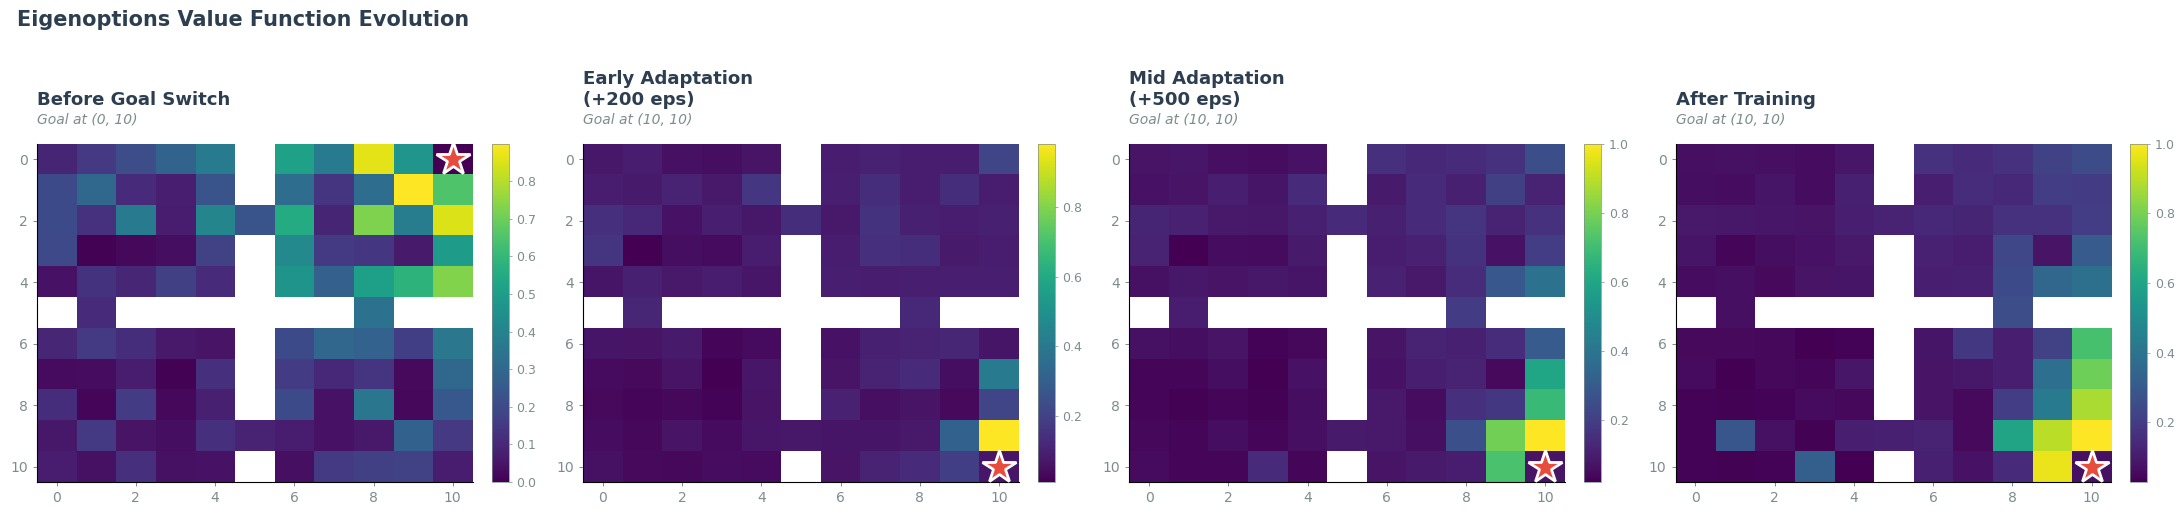

In [14]:
# Plot Eigenoptions value function snapshots across training.
plot_value_evolution(env_eo, q_snapshots, HYPERPARAMS, "Eigenoptions Value Function Evolution")

plt.savefig(os.path.join("perfect plots", "eigenoptions_value_functions.png"), dpi=300, bbox_inches="tight")
plt.show()


### Value Function Evolution (TOC)


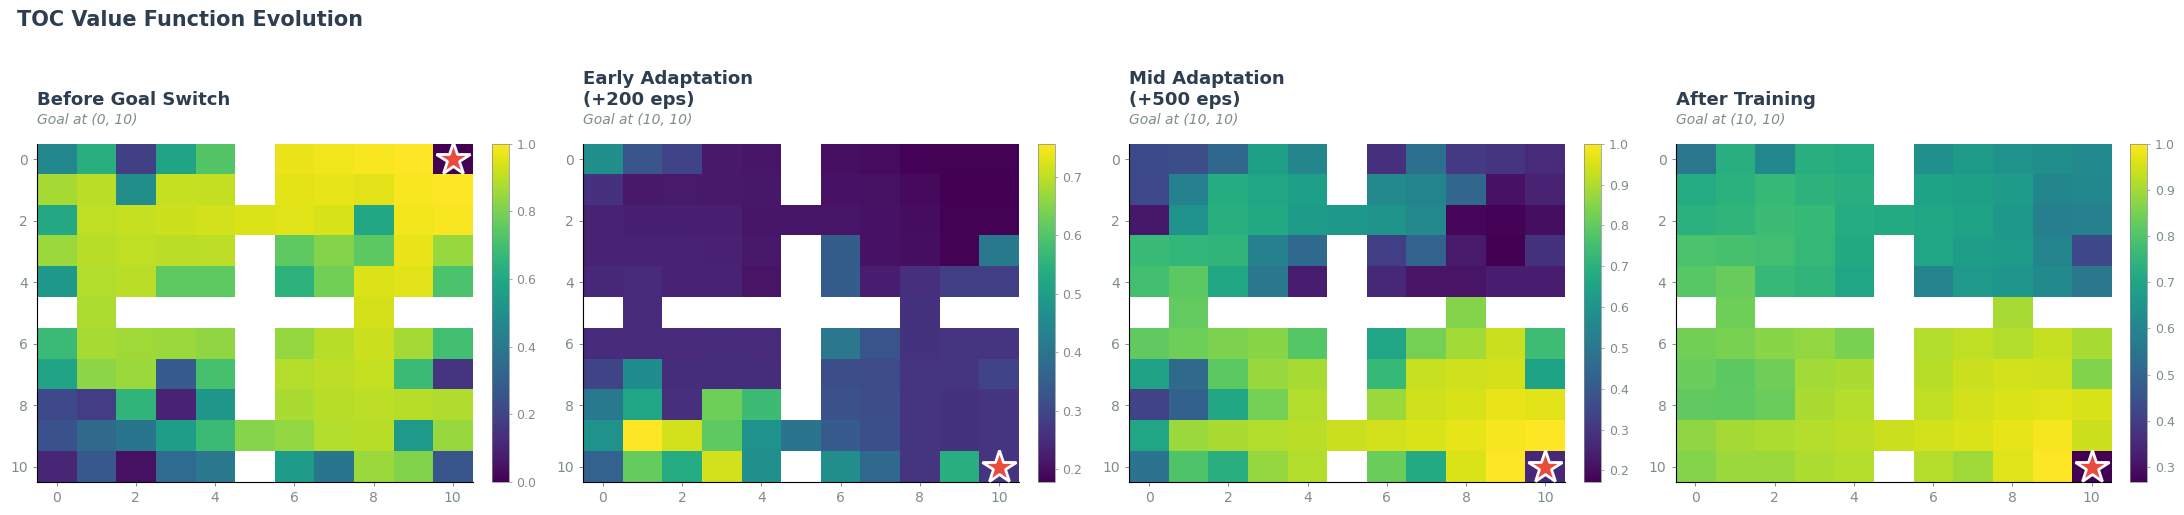

In [15]:
# Plot TOC value function snapshots across training.
plot_value_evolution(env_toc, toc_q_snapshots, HYPERPARAMS, "TOC Value Function Evolution")

plt.savefig(os.path.join("perfect plots", "toc_value_functions.png"), dpi=300, bbox_inches="tight")
plt.show()


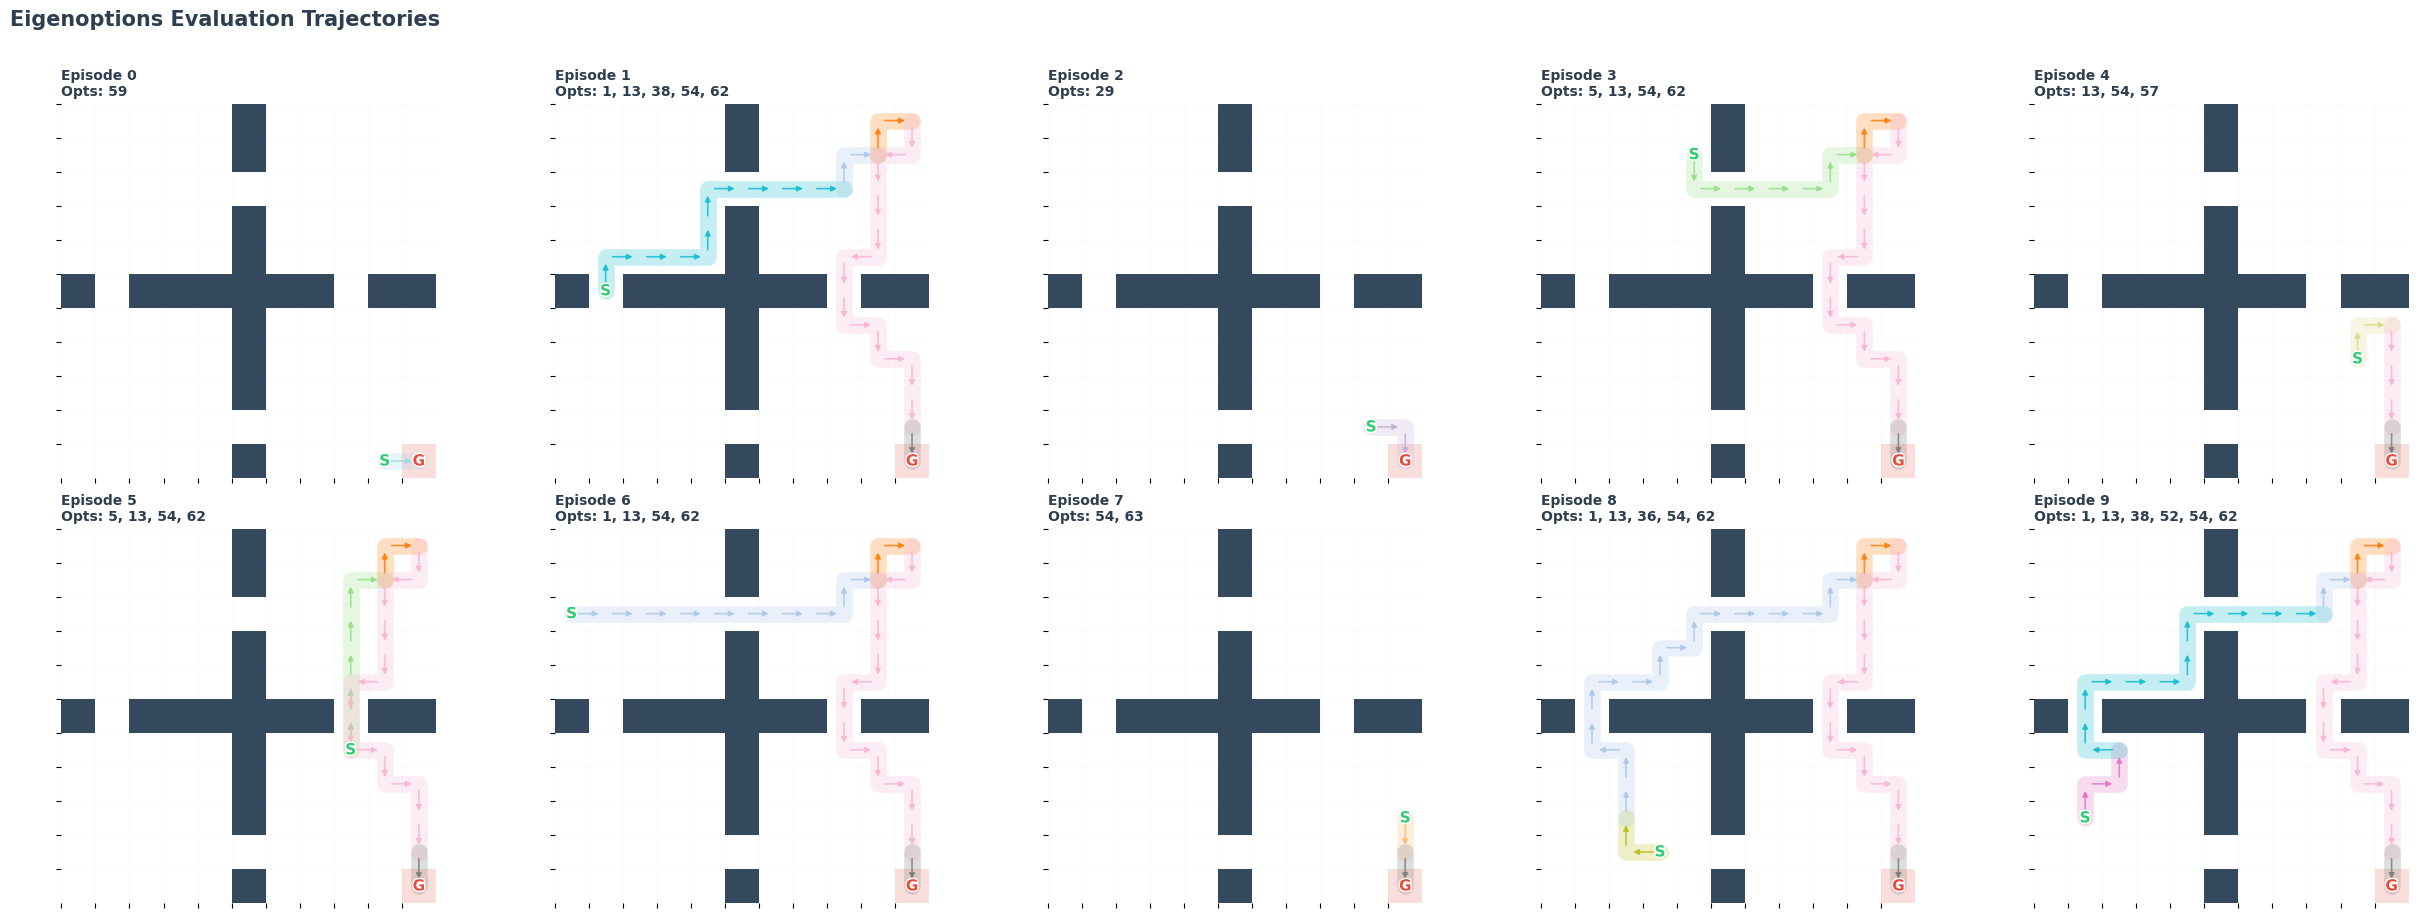

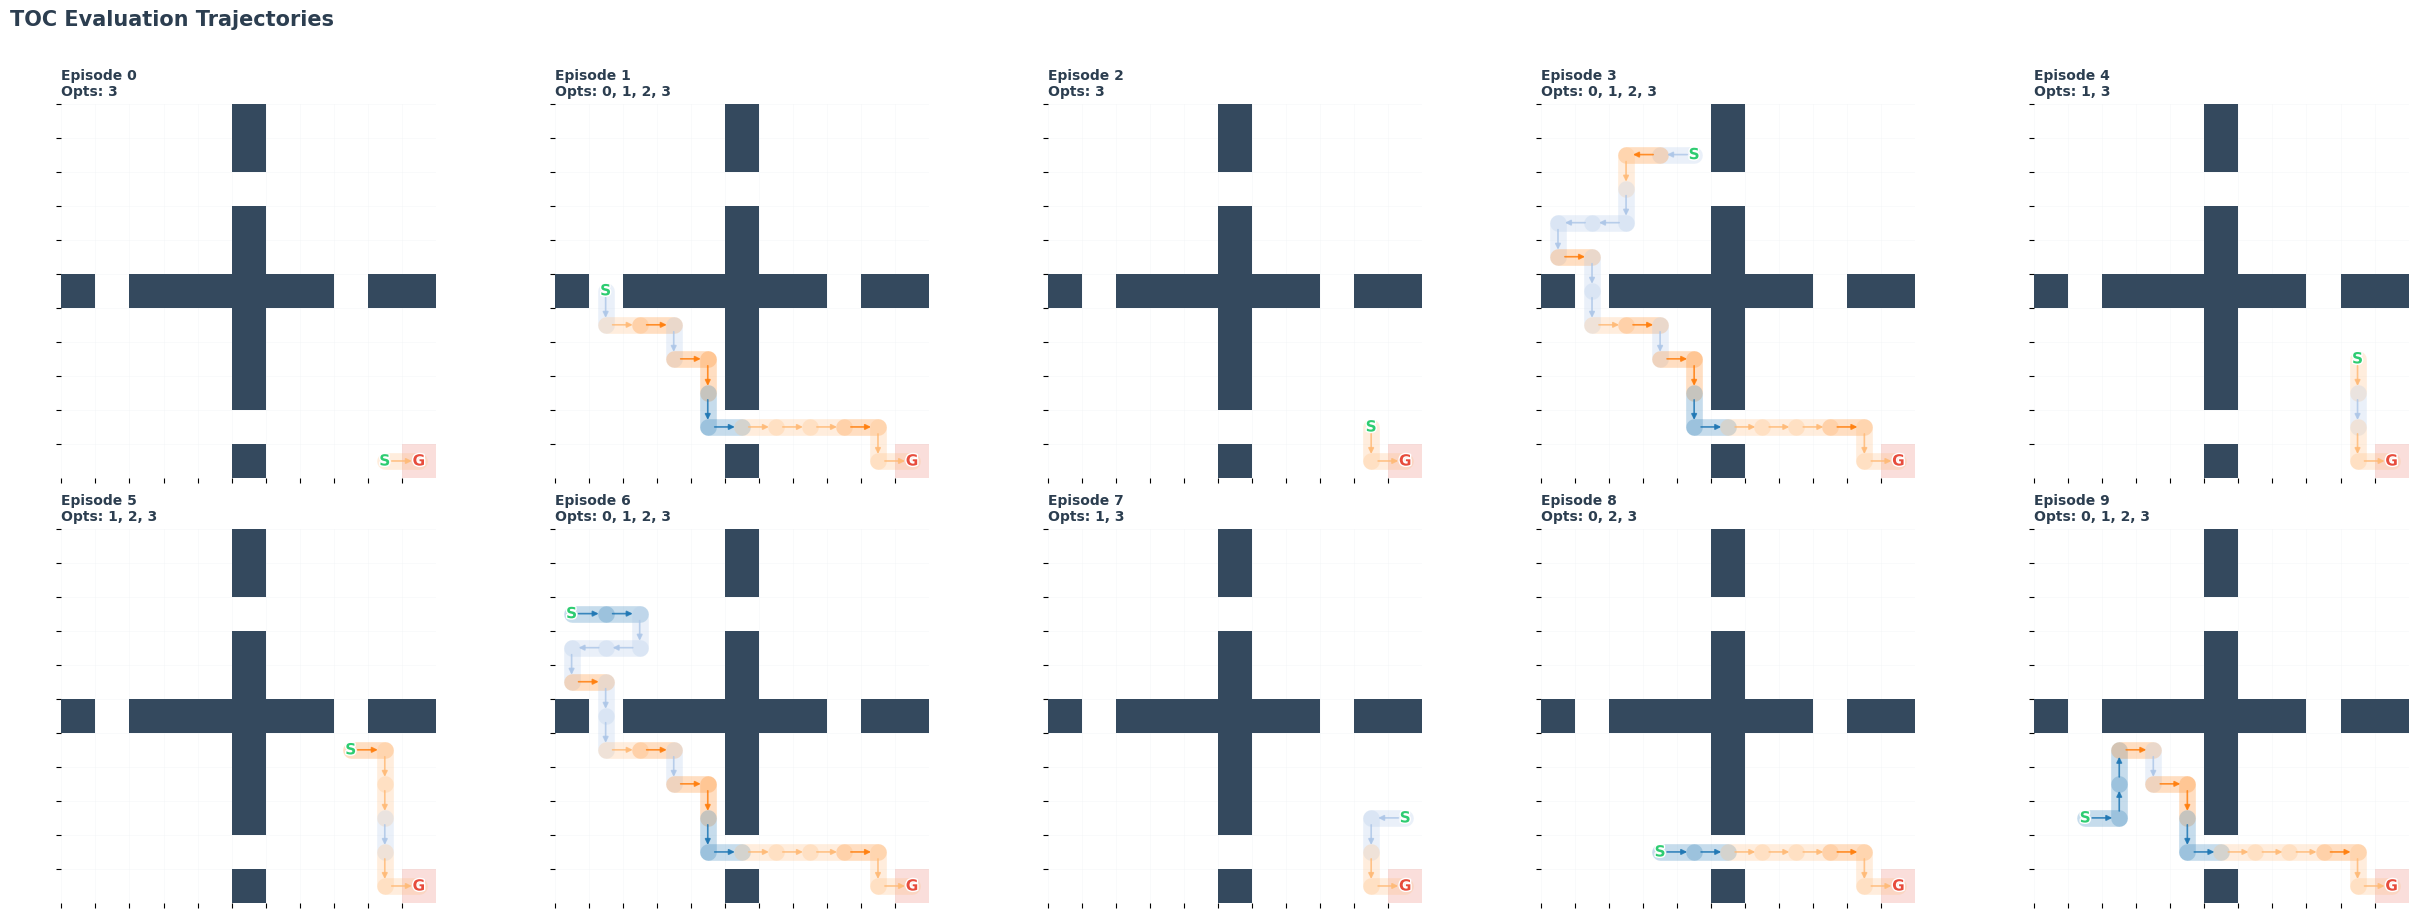

In [16]:
# Evaluate trained agents and plot episode trajectories.
def option_color(idx):
    """Color for option index using tab20 colormap."""
    return plt.get_cmap('tab20')(idx % 20)

def get_action_color(action):
    """Color for a high-level action (0-3 primitive, 4+ option)."""
    if action < 4:
        return COLORS["primitive"]
    return option_color(action - 4)

def plot_episode_trajectories(trajectories, env, start_ep, end_ep, title_prefix="Evaluation"):
    """Grid of episode trajectory plots with colored action segments."""
    episodes_to_plot = [ep for ep in range(start_ep, end_ep + 1) if ep in trajectories]
    n_eps = len(episodes_to_plot)
    if n_eps == 0:
        print(f"No trajectories found between episodes {start_ep} and {end_ep}.")
        return

    cols = min(5, n_eps)
    rows = math.ceil(n_eps / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5.0, rows * 4.5))
    if n_eps == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for idx, ep in enumerate(episodes_to_plot):
        ax = axes[idx]
        traj = trajectories[ep]

        if not traj:
            ax.axis('off')
            continue

        used_options = sorted(set(
            step['high_level_action'] for step in traj if step['high_level_action'] >= 4
        ))
        title_str = f"Episode {ep}"

        if used_options:
            opt_strs = [str(act - 4) for act in used_options]
            title_str += f"\nOpts: {', '.join(opt_strs)}"
        else:
            title_str += "\n(Primitives Only)"

        ax.set_title(title_str, fontsize=10, weight='bold', color=COLORS["text"],
                     loc="left", pad=6)

        ax.set_xlim(0, env.grid_size)
        ax.set_ylim(env.grid_size, 0)
        ax.set_aspect('equal')
        ax.set_xticks(np.arange(env.grid_size))
        ax.set_yticks(np.arange(env.grid_size))
        ax.grid(color=COLORS["grid"], linestyle='-', linewidth=0.4, alpha=0.5)
        ax.set_axisbelow(True)
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        for s in ["top", "right", "left", "bottom"]:
            ax.spines[s].set_visible(False)
        ax.set_facecolor(COLORS["floor"])

        for (r, c) in env.walls:
            ax.add_patch(mpatches.Rectangle((c, r), 1, 1, facecolor=COLORS["wall"], edgecolor="none"))

        gr, gc = env.goal_state
        ax.add_patch(mpatches.Rectangle((gc, gr), 1, 1, facecolor=COLORS["goal"], alpha=0.18, edgecolor="none"))

        start_state = traj[0]['transitions'][0][0]
        ax.text(start_state[1] + 0.5, start_state[0] + 0.5, 'S',
                color=COLORS["start"], weight='bold', fontsize=11,
                ha='center', va='center', zorder=6,
                path_effects=[path_effects.withStroke(linewidth=2, foreground='white')])

        goal_state = env.goal_state
        ax.text(goal_state[1] + 0.5, goal_state[0] + 0.5, 'G',
                color=COLORS["goal"], weight='bold', fontsize=11,
                ha='center', va='center', zorder=6,
                path_effects=[path_effects.withStroke(linewidth=2, foreground='white')])

        for step in traj:
            action = step['high_level_action']
            color = get_action_color(action)

            if step['transitions']:
                path_x = [step['transitions'][0][0][1] + 0.5]
                path_y = [step['transitions'][0][0][0] + 0.5]

                for (state, next_state) in step['transitions']:
                    path_x.append(next_state[1] + 0.5)
                    path_y.append(next_state[0] + 0.5)

                ax.plot(path_x, path_y, color=color, linewidth=12, alpha=0.25,
                        solid_capstyle='round', solid_joinstyle='round', zorder=3)

            for (state, next_state) in step['transitions']:
                y1, x1 = state[0] + 0.5, state[1] + 0.5
                y2, x2 = next_state[0] + 0.5, next_state[1] + 0.5

                ax.add_patch(mpatches.FancyArrowPatch(
                    (x1, y1), (x2, y2),
                    color=color, mutation_scale=8, arrowstyle='-|>',
                    shrinkA=5, shrinkB=5, linewidth=1.2, zorder=4,
                    alpha=0.85,
                ))

    for i in range(n_eps, len(axes)):
        axes[i].axis('off')

    fig_title(fig, f"{title_prefix} Trajectories", y=1.01)
    plt.tight_layout()

def evaluate_smdp(env, Q_table, options, start_states, max_steps, gamma):
    """Greedy rollout of SMDP agent from each start_state; returns trajectory dict."""
    num_primitive = 4  # 0-3 primitive; 4+ = option indices
    trajectories = {}

    for ep, start_state in enumerate(start_states):
        env.reset()
        env.current_state = start_state
        env.current_step = 0
        state_idx = env.get_state_idx()

        current_traj = []
        step = 0

        while step < max_steps:
            valid_actions = list(range(num_primitive))
            for opt_idx, opt in enumerate(options):
                if state_idx in opt["initiation_set"]:
                    valid_actions.append(num_primitive + opt_idx)

            valid_q = Q_table[state_idx, valid_actions]
            max_q = np.max(valid_q)
            best_actions = [a for a, q in zip(valid_actions, valid_q) if q == max_q]
            action_idx = int(np.random.choice(best_actions))

            if action_idx < num_primitive:
                s_state = env.idx_to_state[state_idx]
                _, _, terminated, truncated, _ = env.step(action_idx)
                next_state_idx = env.get_state_idx()
                e_state = env.idx_to_state[next_state_idx]

                current_traj.append({
                    'high_level_action': action_idx,
                    'transitions': [(s_state, e_state)]
                })

                state_idx = next_state_idx
                step += 1

                if terminated or truncated:
                    break
            else:
                option_idx = action_idx - num_primitive
                option = options[option_idx]
                option_policy = option['policy']

                terminated, truncated = False, False
                transitions = []

                while True:
                    if option_policy[state_idx] == 4:  # terminate
                        break

                    primitive_action = option_policy[state_idx]
                    s_state = env.idx_to_state[state_idx]
                    _, _, terminated, truncated, _ = env.step(primitive_action)
                    next_state_idx = env.get_state_idx()
                    e_state = env.idx_to_state[next_state_idx]

                    transitions.append((s_state, e_state))
                    state_idx = next_state_idx
                    step += 1

                    if terminated or truncated or step >= max_steps:
                        break

                if transitions:
                    current_traj.append({
                        'high_level_action': action_idx,
                        'transitions': transitions
                    })

                if terminated or truncated or step >= max_steps:
                    break

        trajectories[ep] = current_traj
    return trajectories

def evaluate_toc(env, policy_over_options, option_policies, option_terminations, start_states, max_steps):
    """Greedy rollout of TOC agent from each start_state; returns trajectory dict."""
    trajectories = {}

    for ep, start_state in enumerate(start_states):
        env.reset()
        env.current_state = start_state
        env.current_step = 0
        state = env.get_state_idx()

        current_traj = []
        current_transitions = []

        option = int(np.argmax(policy_over_options.Q_Omega(state)))
        current_option = option

        step = 0
        while step < max_steps:
            action = int(np.argmax(option_policies[option].Q_U(state)))

            s_state = env.idx_to_state[state]
            _, _, terminated, truncated, _ = env.step(action)
            state = env.get_state_idx()
            e_state = env.idx_to_state[state]

            current_transitions.append((s_state, e_state))
            step += 1

            terminated_option = option_terminations[option].pmf(state) > 0.5

            if terminated_option or terminated or truncated or step >= max_steps:
                if current_transitions:
                    current_traj.append({
                        'high_level_action': current_option + 4,
                        'transitions': current_transitions
                    })
                    current_transitions = []

            if terminated or truncated or step >= max_steps:
                break

            if terminated_option:
                option = int(np.argmax(policy_over_options.Q_Omega(state)))
                current_option = option

        trajectories[ep] = current_traj
    return trajectories

# Fixed start states for reproducible evaluation
np.random.seed(42)
num_eval_episodes = 10
eval_start_states = []
env_eval = FourRoomsEnv(goal_state=HYPERPARAMS["switched_goal"])
while len(eval_start_states) < num_eval_episodes:
    idx = np.random.randint(0, len(env_eval.valid_states))
    state = env_eval.valid_states[idx]
    if state != env_eval.goal_state and state not in eval_start_states:
        eval_start_states.append(state)

eo_eval_trajectories = evaluate_smdp(
    env_eval, final_eo_agent_Q, smdp_options,
    eval_start_states, HYPERPARAMS["max_steps"], HYPERPARAMS["gamma"],
)

po, op, ot = final_toc_agent
toc_eval_trajectories = evaluate_toc(
    env_eval, po, op, ot, eval_start_states, HYPERPARAMS["max_steps"],
)

plot_episode_trajectories(eo_eval_trajectories, env_eval, 0, 9, title_prefix="Eigenoptions Evaluation")
plt.savefig(os.path.join("perfect plots", "eigenoptions_evaluation_trajectories.png"), dpi=300, bbox_inches="tight")
plt.show()

plot_episode_trajectories(toc_eval_trajectories, env_eval, 0, 9, title_prefix="TOC Evaluation")
plt.savefig(os.path.join("perfect plots", "toc_evaluation_trajectories.png"), dpi=300, bbox_inches="tight")
plt.show()
